# Importing Libraries 

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
base_dir = Path('../artifacts')
PROCESSED_DIR = base_dir / 'processed_data'
MODEL_DIR = base_dir / 'models'
FIGURE_DIR = base_dir / 'figures'
FEATURE_DIR = base_dir / 'features'
METRICS_DIR     = base_dir / 'metrics'       
INTERIM_DIR     = base_dir / 'interim_data'  
PREDICTIONS_DIR = base_dir / 'predictions'



directories = [
    PROCESSED_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    FEATURE_DIR,
    METRICS_DIR,
    INTERIM_DIR,
    PREDICTIONS_DIR
]


for path in directories:
    path.mkdir(parents=True, exist_ok=True)



 

# Loading the Data

In [3]:
df = pd.read_csv(f'{PROCESSED_DIR}/dc_features.csv', parse_dates=['date'])
print(df.shape)
print(df.dtypes)

(49233, 23)
date                        datetime64[us]
home_team                              str
away_team                              str
home_goals                         float64
away_goals                         float64
home_win                             int64
away_win                             int64
draw                                 int64
goal_diff                          float64
result                               int64
is_competitive                        bool
home_dc_attack_strength            float64
home_dc_defense_strength           float64
away_dc_attack_strength            float64
away_dc_defense_strength           float64
dc_attack_diff                     float64
dc_defense_diff                    float64
home_dc_weight_sum                 float64
away_dc_weight_sum                 float64
elo_diff                           float64
neutral                              int64
home_is_host                         int64
home_tournament_stage                int64

In [4]:
df.head()

,date,home_team,away_team,home_goals,away_goals,home_win,away_win,draw,goal_diff,result,...,away_dc_attack_strength,away_dc_defense_strength,dc_attack_diff,dc_defense_diff,home_dc_weight_sum,away_dc_weight_sum,elo_diff,neutral,home_is_host,home_tournament_stage
0,1872-11-30,Scotland,England,0.0,0.0,0,0,1,0.0,1,...,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0,0,0
1,1873-03-08,England,Scotland,4.0,2.0,1,0,0,2.0,0,...,1.0,1.0,0.0,0.0,0.0,0.0,5.602600,0,0,0
2,1874-03-07,Scotland,England,2.0,1.0,1,0,0,1.0,0,...,1.0,1.0,0.0,0.0,0.0,0.0,-26.754938,0,0,0
3,1875-03-06,England,Scotland,2.0,2.0,0,0,1,0.0,1,...,1.0,1.0,0.0,0.0,0.0,0.0,10.909891,0,0,0
4,1876-03-04,Scotland,England,3.0,0.0,1,0,0,3.0,0,...,1.0,1.0,0.0,0.0,0.0,0.0,-4.733783,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49233 entries, 0 to 49232
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      49233 non-null  datetime64[us]
 1   home_team                 49233 non-null  str           
 2   away_team                 49233 non-null  str           
 3   home_goals                49233 non-null  float64       
 4   away_goals                49233 non-null  float64       
 5   home_win                  49233 non-null  int64         
 6   away_win                  49233 non-null  int64         
 7   draw                      49233 non-null  int64         
 8   goal_diff                 49233 non-null  float64       
 9   result                    49233 non-null  int64         
 10  is_competitive            49233 non-null  bool          
 11  home_dc_attack_strength   49233 non-null  float64       
 12  home_dc_defense_strength  492

# Train / Valid Split 

In [6]:
if 'is_competitive' not in df.columns:
    df['is_competitive'] = True
 
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()
 
train = train_df[train_df['date'] <  '2024-01-01'].copy()
valid = train_df[train_df['date'] >= '2024-01-01'].copy()
 
print(f"\nTrain : {len(train):,} matches  ({train['date'].dt.year.min()}–{train['date'].dt.year.max()})")
print(f"Valid : {len(valid):,} matches  ({valid['date'].dt.year.min()}–{valid['date'].dt.year.max()})")


Train : 14,855 matches  (2000–2023)
Valid : 1,776 matches  (2024–2026)


# Load Poisson models 

In [7]:

model_home   = joblib.load(f'{MODEL_DIR}/poisson_home.pkl')
model_away   = joblib.load(f'{MODEL_DIR}/poisson_away.pkl')
scaler       = joblib.load(f'{MODEL_DIR}/poisson_scaler.pkl')
feature_cols = pd.read_csv(f'{FEATURE_DIR}/poisson_feature_cols.csv').iloc[:, 0].tolist()

print(f"Poisson models loaded")
print(f"Feature cols : {len(feature_cols)}")


df_poisson = pd.read_csv(f'{PROCESSED_DIR}/poisson_features.csv', parse_dates=['date'])

train_poisson = df_poisson[
    df_poisson['is_competitive'] & 
    (df_poisson['date'] >= '2000-01-01') & 
    (df_poisson['date'] <  '2024-01-01')
].copy()

valid_poisson = df_poisson[
    df_poisson['is_competitive'] & 
    (df_poisson['date'] >= '2024-01-01')
].copy()

X_train_scaled = scaler.transform(train_poisson[feature_cols].fillna(0))
X_valid_scaled = scaler.transform(valid_poisson[feature_cols].fillna(0))

train['lambda_h'] = model_home.predict(X_train_scaled)
train['lambda_a'] = model_away.predict(X_train_scaled)

print(f"\nPoisson λ added to train set")
print(f"  Mean lambda_h : {train['lambda_h'].mean():.3f}")
print(f"  Mean lambda_a : {train['lambda_a'].mean():.3f}")

Poisson models loaded
Feature cols : 19

Poisson λ added to train set
  Mean lambda_h : 1.698
  Mean lambda_a : 1.155


# Dixon-Coles Low-Score Correction 

In [8]:
 
def dc_correction(home_goals, away_goals, lambda_h, lambda_a, rho):
    if home_goals == 0 and away_goals == 0:
        return 1 - lambda_h * lambda_a * rho
    elif home_goals == 0 and away_goals == 1:
        return 1 + lambda_h * rho
    elif home_goals == 1 and away_goals == 0:
        return 1 + lambda_a * rho
    elif home_goals == 1 and away_goals == 1:
        return 1 - rho
    return 1.0

# Recency Weights

In [9]:
def compute_weights(dates, reference_date, half_life_days=180.0):
    lam      = np.log(2) / half_life_days
    days_ago = (reference_date - dates).dt.days.values
    return np.exp(-lam * days_ago)

reference_date    = train['date'].max()
train             = train.copy()
train['weight']   = compute_weights(train['date'], reference_date)

print(f"Reference date : {reference_date.date()}")
print(f"Weight range   : {train['weight'].min():.4f} – {train['weight'].max():.4f}")

Reference date : 2023-12-02
Weight range   : 0.0000 – 1.0000


# Vectorised NLL — fit only rho 

In [10]:


lambda_h_arr   = train['lambda_h'].values
lambda_a_arr   = train['lambda_a'].values
home_goals_arr = train['home_goals'].values.astype(int)
away_goals_arr = train['away_goals'].values.astype(int)
weights_arr    = train['weight'].values


def neg_log_likelihood_rho(rho_arr):
    rho = rho_arr[0]

    log_p_h = poisson.logpmf(home_goals_arr, lambda_h_arr)
    log_p_a = poisson.logpmf(away_goals_arr, lambda_a_arr)

    tau = np.ones(len(home_goals_arr))

    m00 = (home_goals_arr == 0) & (away_goals_arr == 0)
    m01 = (home_goals_arr == 0) & (away_goals_arr == 1)
    m10 = (home_goals_arr == 1) & (away_goals_arr == 0)
    m11 = (home_goals_arr == 1) & (away_goals_arr == 1)

    tau[m00] = 1 - lambda_h_arr[m00] * lambda_a_arr[m00] * rho
    tau[m01] = 1 + lambda_h_arr[m01] * rho
    tau[m10] = 1 + lambda_a_arr[m10] * rho
    tau[m11] = 1 - rho

    valid   = tau > 0
    log_tau = np.where(valid, np.log(np.maximum(tau, 1e-10)), 0.0)

    return -(weights_arr * (log_p_h + log_p_a + log_tau)).sum()


print("\nFitting rho on top of Poisson λ...")

result_rho = minimize(
    neg_log_likelihood_rho,
    x0=[-0.1],
    method='L-BFGS-B',
    bounds=[(-0.99, 0.0)],
)

rho_fit = result_rho.x[0]

print(f"Converged : {result_rho.success}")
print(f"Message   : {result_rho.message}")
print(f"Fitted rho: {rho_fit:.6f}  (negative = draws boosted)")
 


Fitting rho on top of Poisson λ...
Converged : True
Message   : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Fitted rho: -0.094717  (negative = draws boosted)


# Predicting on Validation Set

In [11]:
MAX_GOALS = 10

def predict_dc(lambda_h, lambda_a):
    """
    Build score matrix using Poisson λ + DC correction.
    λ values come from the Poisson model — not fitted here.
    """
    score_matrix = np.zeros((MAX_GOALS, MAX_GOALS))
    for hg in range(MAX_GOALS):
        for ag in range(MAX_GOALS):
            p_h  = poisson.pmf(hg, lambda_h)
            p_a  = poisson.pmf(ag, lambda_a)
            tau  = dc_correction(hg, ag, lambda_h, lambda_a, rho_fit)
            score_matrix[hg, ag] = max(p_h * p_a * tau, 0)

    score_matrix /= score_matrix.sum()

    return {
        'prob_home_win': round(np.tril(score_matrix, k=-1).sum(), 4),
        'prob_draw':     round(np.trace(score_matrix), 4),
        'prob_away_win': round(np.triu(score_matrix, k=1).sum(), 4),
        'score_matrix':  score_matrix,
    }


print("\nGenerating predictions on validation set...")

# Get Poisson λ for validation set
lambda_h_valid = model_home.predict(X_valid_scaled)
lambda_a_valid = model_away.predict(X_valid_scaled)

records = []
for i, row in enumerate(valid.itertuples(index=False)):
    pred = predict_dc(lambda_h_valid[i], lambda_a_valid[i])
    records.append({
        'date':            row.date,
        'home_team':       row.home_team,
        'away_team':       row.away_team,
        'home_goals':      row.home_goals,
        'away_goals':      row.away_goals,
        'result':          row.result,
        'pred_home_goals': round(lambda_h_valid[i], 4),
        'pred_away_goals': round(lambda_a_valid[i], 4),
        'prob_home_win':   pred['prob_home_win'],
        'prob_draw':       pred['prob_draw'],
        'prob_away_win':   pred['prob_away_win'],
    })

valid_preds = pd.DataFrame(records)
print(f"Predictions generated : {len(valid_preds):,} / {len(valid):,} matches")

print("\nSample predictions:")
print(valid_preds[[
    'date', 'home_team', 'away_team',
    'home_goals', 'pred_home_goals',
    'away_goals', 'pred_away_goals'
]].head(10).to_string(index=False))


Generating predictions on validation set...
Predictions generated : 1,776 / 1,776 matches

Sample predictions:
      date            home_team         away_team  home_goals  pred_home_goals  away_goals  pred_away_goals
2024-01-12                Qatar           Lebanon         3.0           2.7128         0.0           0.4172
2024-01-13                China        Tajikistan         0.0           1.4848         0.0           0.9933
2024-01-13            Australia             India         2.0           2.2404         0.0           0.5224
2024-01-13           Uzbekistan             Syria         0.0           1.3744         0.0           0.9554
2024-01-13          Ivory Coast     Guinea-Bissau         2.0           1.7625         0.0           0.6030
2024-01-14              Nigeria Equatorial Guinea         1.0           1.5342         1.0           0.9408
2024-01-14                Japan           Vietnam         4.0           2.1653         2.0           0.5493
2024-01-14              

# Goal Prediction Metrics

In [12]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
y_valid_home = valid_preds['home_goals']
y_valid_away = valid_preds['away_goals']
 
mae_home  = mean_absolute_error(y_valid_home, valid_preds['pred_home_goals'])
mae_away  = mean_absolute_error(y_valid_away, valid_preds['pred_away_goals'])
rmse_home = rmse(y_valid_home, valid_preds['pred_home_goals'])
rmse_away = rmse(y_valid_away, valid_preds['pred_away_goals'])
 
print("\n Goal Prediction Metrics ")
print(f"  Home goals  →  MAE: {mae_home:.4f}  |  RMSE: {rmse_home:.4f}")
print(f"  Away goals  →  MAE: {mae_away:.4f}  |  RMSE: {rmse_away:.4f}")
 
print(f"\n  Mean pred home : {valid_preds['pred_home_goals'].mean():.3f}  (actual: {y_valid_home.mean():.3f})")
print(f"  Mean pred away : {valid_preds['pred_away_goals'].mean():.3f}  (actual: {y_valid_away.mean():.3f})")
 
 



 Goal Prediction Metrics 
  Home goals  →  MAE: 0.7380  |  RMSE: 0.9141
  Away goals  →  MAE: 0.6426  |  RMSE: 0.8125

  Mean pred home : 1.588  (actual: 1.588)
  Mean pred away : 1.142  (actual: 1.158)


# Scatter — Predicted vs Actual Goals

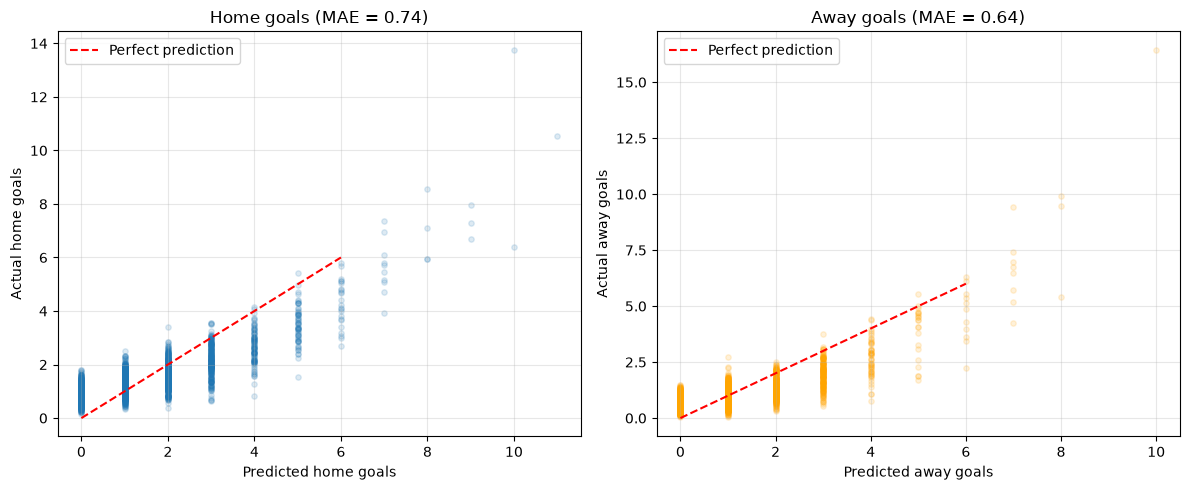

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(y_valid_home, valid_preds['pred_home_goals'], alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Predicted home goals')
axes[0].set_ylabel('Actual home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
axes[1].scatter(y_valid_away, valid_preds['pred_away_goals'], alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Predicted away goals')
axes[1].set_ylabel('Actual away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

# Outcome Evaluation

In [14]:
def predict_outcome(p_home, p_draw, p_away, draw_threshold=0.28):
    """
    0 = Home Win, 1 = Draw, 2 = Away Win
    If draw probability exceeds threshold predict draw.
    Otherwise take argmax of home/away.
    """
    if p_draw >= draw_threshold:
        return 1
    return 0 if p_home >= p_away else 2

In [15]:
def evaluate_outcome(valid, draw_threshold=0.28):
    """Full evaluation block: accuracy + confusion matrix + classification report."""
    valid = valid.copy()
    valid['pred_result'] = valid.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'],
            draw_threshold
        ), axis=1
    )
 
    accuracy = (valid['pred_result'] == valid['result']).mean()
    print(f"\n Outcome Accuracy (draw_threshold={draw_threshold:.2f}) ")
    print(f"  Correct outcome predicted: {accuracy:.2%}")
 
    cm = confusion_matrix(valid['result'], valid['pred_result'], labels=[0, 1, 2])
    print("\n Confusion Matrix (rows=actual, cols=predicted)")
    print(pd.DataFrame(
        cm,
        index  =['Actual HW', 'Actual Draw', 'Actual AW'],
        columns=['Pred HW',   'Pred Draw',   'Pred AW']
    ))
 
    print("\n Classification Report ")
    print(classification_report(
        valid['result'], valid['pred_result'],
        target_names=['HomeWin', 'Draw', 'AwayWin'],
        zero_division=0
    ))

In [16]:

  
# Default argmax
print("=" * 60)
print("DEFAULT: argmax ")
print("=" * 60)
 
valid_preds['pred_result'] = valid_preds[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1)
valid_preds['pred_result'] = valid_preds['pred_result'].map({
    'prob_home_win': 0,
    'prob_draw':     1,
    'prob_away_win': 2,
})
 
accuracy = (valid_preds['pred_result'] == valid_preds['result']).mean()
print(f"\n  Correct outcome predicted: {accuracy:.2%}")
 
cm = confusion_matrix(valid_preds['result'], valid_preds['pred_result'], labels=[0, 1, 2])
print("\n Confusion Matrix ")
print(pd.DataFrame(
    cm,
    index  =['Actual HW', 'Actual Draw', 'Actual AW'],
    columns=['Pred HW',   'Pred Draw',   'Pred AW']
))
print("\n Classification Report ")
print(classification_report(
    valid_preds['result'], valid_preds['pred_result'],
    target_names=['HomeWin', 'Draw', 'AwayWin'],
    zero_division=0
))
 
 

DEFAULT: argmax 

  Correct outcome predicted: 74.16%

 Confusion Matrix 
             Pred HW  Pred Draw  Pred AW
Actual HW        817          0        8
Actual Draw      284          0      129
Actual AW         38          0      500

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.72      0.99      0.83       825
        Draw       0.00      0.00      0.00       413
     AwayWin       0.78      0.93      0.85       538

    accuracy                           0.74      1776
   macro avg       0.50      0.64      0.56      1776
weighted avg       0.57      0.74      0.64      1776



In [17]:
# Threshold tuning
print("\n" + "=" * 60)
print("TUNING: Find best draw threshold")
print("=" * 60)
 
thresholds = np.arange(0.20, 0.45, 0.01)
results    = []
 
for thresh in thresholds:
    preds = valid_preds.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'], thresh
        ), axis=1
    )
    acc       = (preds == valid_preds['result']).mean()
    draw_rate = (preds == 1).mean()
    results.append({
        'threshold':      round(thresh, 2),
        'accuracy':       round(acc, 4),
        'pred_draw_rate': round(draw_rate, 4),
    })
 
df_thresh   = pd.DataFrame(results)
best_row    = df_thresh.loc[df_thresh['accuracy'].idxmax()]
best_thresh = best_row['threshold']
best_acc    = best_row['accuracy']
 
print(f"\n  Actual draw rate in validation : {(valid_preds['result'] == 1).mean():.2%}")
print(f"\n  Best threshold : {best_thresh:.2f}")
print(f"  Best accuracy  : {best_acc:.2%}")
print(f"\n  Threshold scan:")
print(df_thresh.to_string(index=False))
 


TUNING: Find best draw threshold

  Actual draw rate in validation : 23.25%

  Best threshold : 0.30
  Best accuracy  : 81.31%

  Threshold scan:
 threshold  accuracy  pred_draw_rate
      0.20    0.5270          0.7044
      0.21    0.5507          0.6807
      0.22    0.5816          0.6498
      0.23    0.6126          0.6188
      0.24    0.6441          0.5873
      0.25    0.6757          0.5524
      0.26    0.7072          0.5163
      0.27    0.7410          0.4724
      0.28    0.7703          0.4150
      0.29    0.7928          0.3502
      0.30    0.8131          0.2432
      0.31    0.7872          0.1081
      0.32    0.7461          0.0180
      0.33    0.7421          0.0006
      0.34    0.7416          0.0000
      0.35    0.7416          0.0000
      0.36    0.7416          0.0000
      0.37    0.7416          0.0000
      0.38    0.7416          0.0000
      0.39    0.7416          0.0000
      0.40    0.7416          0.0000
      0.41    0.7416          0.0000
  

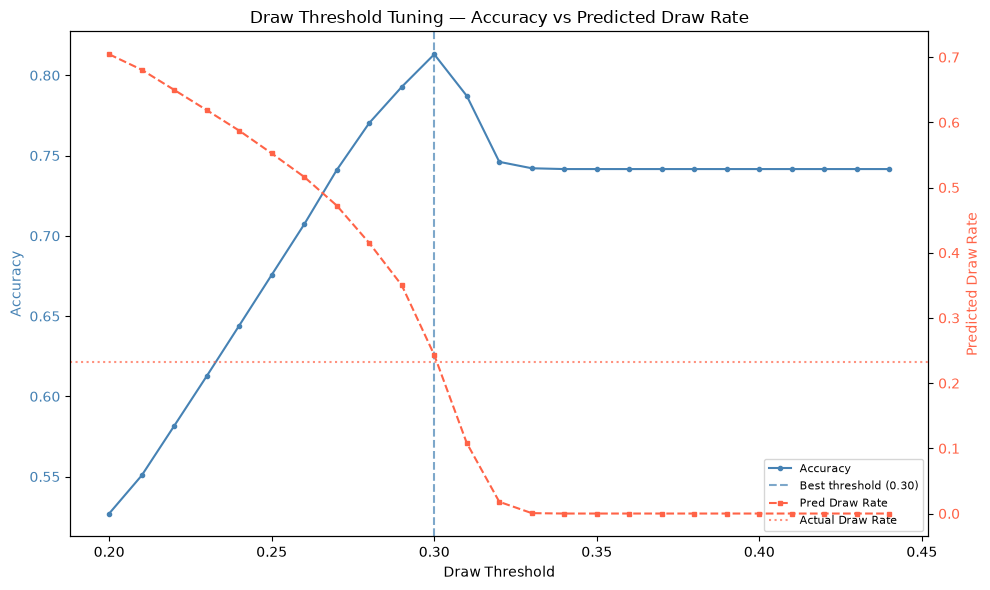


FINAL EVALUATION — draw_threshold = 0.30

 Outcome Accuracy (draw_threshold=0.30) 
  Correct outcome predicted: 81.25%

 Confusion Matrix (rows=actual, cols=predicted)
             Pred HW  Pred Draw  Pred AW
Actual HW        750         75        0
Actual Draw      127        264       22
Actual AW         15         94      429

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.84      0.91      0.87       825
        Draw       0.61      0.64      0.62       413
     AwayWin       0.95      0.80      0.87       538

    accuracy                           0.81      1776
   macro avg       0.80      0.78      0.79      1776
weighted avg       0.82      0.81      0.81      1776



In [38]:
# Threshold tuning plot
fig, ax1 = plt.subplots(figsize=(10, 6))
 
ax1.plot(df_thresh['threshold'], df_thresh['accuracy'],
         color='steelblue', marker='o', markersize=3, label='Accuracy')
ax1.axvline(best_thresh, color='steelblue', linestyle='--', alpha=0.7,
            label=f'Best threshold ({best_thresh:.2f})')
ax1.set_xlabel('Draw Threshold')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
 
ax2 = ax1.twinx()
ax2.plot(df_thresh['threshold'], df_thresh['pred_draw_rate'],
         color='tomato', marker='s', markersize=3, linestyle='--', label='Pred Draw Rate')
ax2.axhline((valid_preds['result'] == 1).mean(), color='tomato', linestyle=':',
            alpha=0.7, label='Actual Draw Rate')
ax2.set_ylabel('Predicted Draw Rate', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
 
plt.title('Draw Threshold Tuning — Accuracy vs Predicted Draw Rate')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/dc_threshold_tuning.png', dpi=150)
plt.show()
 
 
# Final evaluation with best threshold
print("\n" + "=" * 60)
print(f"FINAL EVALUATION — draw_threshold = {best_thresh:.2f}")
print("=" * 60)
 
evaluate_outcome(valid_preds, draw_threshold=best_thresh)

# Goal Distribution

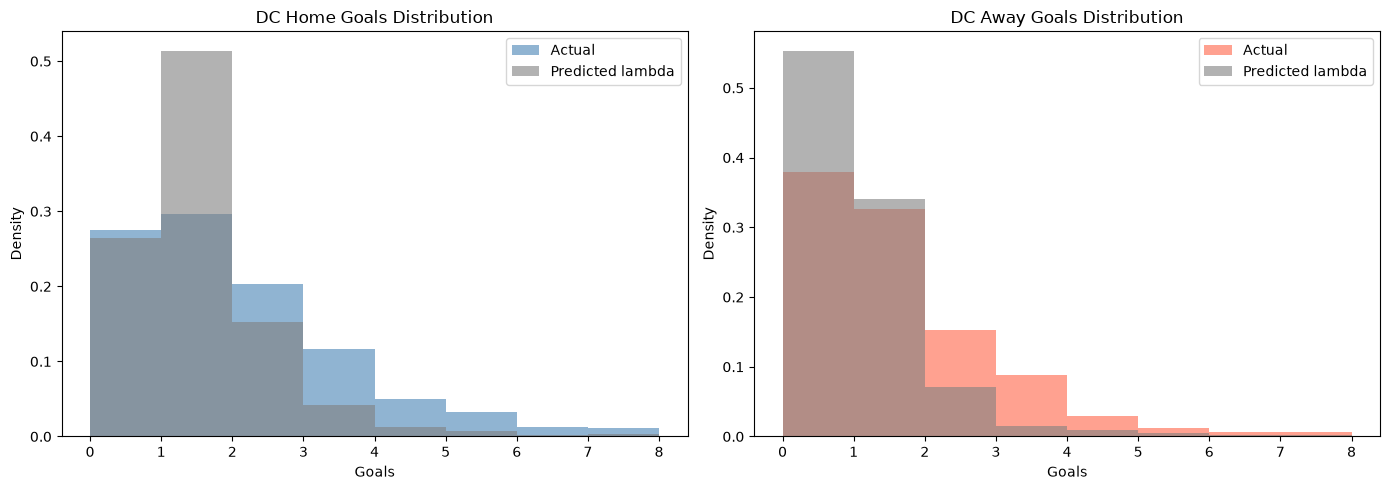

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col_actual, col_pred, title, color in [
    (axes[0], 'home_goals', 'pred_home_goals', 'Home Goals', 'steelblue'),
    (axes[1], 'away_goals', 'pred_away_goals', 'Away Goals', 'tomato'),
]:
    ax.hist(valid_preds[col_actual].clip(0, 7), bins=range(9),
            alpha=0.6, label='Actual', color=color, density=True)
    ax.hist(valid_preds[col_pred].clip(0, 7), bins=range(9),
            alpha=0.6, label='Predicted lambda', color='gray', density=True)
    ax.set_title(f'DC {title} Distribution')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Density')
    ax.legend()
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/dc_goal_distribution.png', dpi=150)
plt.show()

# Score Probability Heatmap

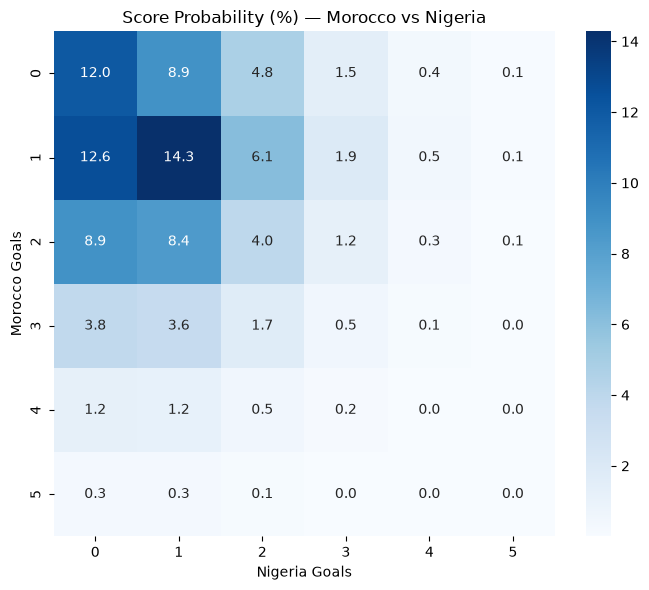


Morocco vs Nigeria:
  lambda_home : 1.2872
  lambda_away : 0.9420
  P(Home Win) : 43.19%
  P(Draw)     : 30.81%
  P(Away Win) : 26.00%


In [36]:
example_home = 'Morocco'
example_away = 'Nigeria'

# Get features for this match from valid_preds
ex_row = valid_preds[
    (valid_preds['home_team'] == example_home) &
    (valid_preds['away_team'] == example_away)
]

if len(ex_row) > 0:
    lh = ex_row.iloc[0]['pred_home_goals']
    la = ex_row.iloc[0]['pred_away_goals']
    ex = predict_dc(lh, la)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        ex['score_matrix'][:6, :6] * 100,
        annot=True, fmt='.1f', cmap='Blues',
        xticklabels=range(6), yticklabels=range(6), ax=ax
    )
    ax.set_xlabel(f'{example_away} Goals')
    ax.set_ylabel(f'{example_home} Goals')
    ax.set_title(f'Score Probability (%) — {example_home} vs {example_away}')
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/dc_score_heatmap.png', dpi=150)
    plt.show()

    print(f"\n{example_home} vs {example_away}:")
    print(f"  lambda_home : {lh:.4f}")
    print(f"  lambda_away : {la:.4f}")
    print(f"  P(Home Win) : {ex['prob_home_win']:.2%}")
    print(f"  P(Draw)     : {ex['prob_draw']:.2%}")
    print(f"  P(Away Win) : {ex['prob_away_win']:.2%}")
else:
    print(f"{example_home} vs {example_away} not found in validation set — pick another example.")

# Saving the Model 

In [37]:
dc_params = {
    'rho': float(rho_fit),
}
joblib.dump(dc_params, f'{MODEL_DIR}/dc_rho.pkl')

# ── Save threshold config ─────────────────────────────────────
thresh_cfg = {
    'draw_threshold':      float(best_thresh),
    'validation_accuracy': float(best_acc),
    'actual_draw_rate':    round((valid_preds['result'] == 1).mean(), 4),
    'rho':                 float(rho_fit),
}
with open(f'{METRICS_DIR}/dc_threshold.json', 'w') as f:
    json.dump(thresh_cfg, f, indent=2)

# ── Save validation predictions ───────────────────────────────
valid_preds.to_csv(f'{PREDICTIONS_DIR}/dc_valid_preds.csv', index=False)

print("\nSaved:")
print(f"  models/      → dc_rho.pkl")
print(f"  metrics/     → dc_threshold.json")
print(f"  predictions/ → dc_valid_preds.csv")
print(json.dumps(thresh_cfg, indent=2))


Saved:
  models/      → dc_rho.pkl
  metrics/     → dc_threshold.json
  predictions/ → dc_valid_preds.csv
{
  "draw_threshold": 0.3,
  "validation_accuracy": 0.8131,
  "actual_draw_rate": 0.2325,
  "rho": -0.09471697254335844
}
